## Sessiz Müşteri Riski: Banka Uygulaması Yorumlarından Gizli Müşteri Kaybı Sinyallerinin Tespiti

In [1]:
%pip install matplotlib seaborn wordcloud
#%pip install transformers torch tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd  
import numpy as np 
import time 
import os 
from google_play_scraper import Sort, reviews
from datetime import datetime as dt
import re
import emoji
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



c:\Users\casper\miniconda3\envs\PythonProject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("outputs/ham_veri_v1.csv")

In [3]:
# DÜZELTİLMİŞ FONKSİYON
def temizle_bert_yeni(metin):
    metin = str(metin)
    metin = metin.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    metin = re.sub(r"http\S+|www\S+", "", metin)
    metin = re.sub(r"\s+", " ", metin).strip()
    return metin  

def temizle_keyword_yeni(metin):
    metin = str(metin)
    metin = emoji.replace_emoji(metin, replace='') # Emojiler silindi
    metin = metin.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    metin = re.sub(r"http\S+|www\S+", "", metin)
    metin = re.sub(r"[^a-zA-ZğüşıöçĞÜŞİÖÇ\s]", "", metin)
    metin = re.sub(r"\s+", " ", metin).strip()
    metin = metin.lower()
    return metin

df["yorum_bert"] = df["yorum"].apply(temizle_bert_yeni)
df["yorum_keyword"] = df["yorum"].apply(temizle_keyword_yeni)

df = df.dropna(subset=["yorum_bert"])
df = df[df["yorum_bert"] != ""]

YENI_TEMIZ_DOSYA = os.path.join("outputs", "temiz_veri_v2_emoji_korumali.csv")
df.to_csv(YENI_TEMIZ_DOSYA, index=False, encoding="utf-8-sig")

In [4]:
# TEMEL İSTATİSTİKLER
print("BANKA BAZINDA ÖZET")
ozet=df.groupby("banka").agg(yorum_sayisi =("yorum","count"),
                             ortalama_ouan = ("puan","mean"),
                             en_eski_tarih = ("tarih","min"),
                             en_yeni_tarih = ("tarih","max")).round(2)

print(ozet)

print("═" * 60)
print("PUAN DAĞILIMI BANKA BAZINDA TÜM BANKALAR")
print(df["puan"].value_counts().sort_index())

BANKA BAZINDA ÖZET
         yorum_sayisi  ortalama_ouan        en_eski_tarih        en_yeni_tarih
banka                                                                         
Banka A          2000           3.41  2026-02-10 12:28:18  2026-06-15 14:16:49
Banka B          2000           3.41  2026-03-28 15:45:07  2026-06-15 16:46:10
Banka C          2000           3.56  2025-10-18 16:59:26  2026-06-15 15:56:58
Banka D          2000           3.76  2026-04-15 07:24:40  2026-06-15 16:53:29
Banka E          2000           4.30  2026-05-07 18:25:01  2026-06-15 15:33:21
════════════════════════════════════════════════════════════
PUAN DAĞILIMI BANKA BAZINDA TÜM BANKALAR
puan
1    2758
2     269
3     355
4     552
5    6066
Name: count, dtype: int64


In [5]:
df.groupby(["uygulama_versiyonu"])["puan"].mean().sort_values(ascending=False)


uygulama_versiyonu
1.1.7     5.0
10.6.1    5.0
10.2.1    5.0
15.9      5.0
11.9      5.0
         ... 
8.3.0     1.0
8.6.1     1.0
8.7.0     1.0
9.5       1.0
9.9       1.0
Name: puan, Length: 170, dtype: float64

In [6]:
# 7.PUAN-METİN TUTARSIZLIĞI
olumsuz_kelimeler = ["kötü", "berbat", "rezalet", "dolandır", "çöktü", "çöküyor","yapamıyor","sıkıntılı","problem"
    "sorun", "hata", "şikayet", "yetersiz", "iptal", "kapatıyorum","iğrenç","kalitesiz","bulamıyor","yapılmıyor"
    "geçiyorum", "memnun değil", "tavsiye etmem", "rezil", "saçma","eksi","gelmiyor","olmuyor","sakın",
    "açılmıyor", "donuyor", "çalışmıyor"]

olumlu_kelimeler = ["teşekkür", "harika", "süper", "çok iyi", "mükemmel", "şık","etkili","faydalı","kaliteli","favori"
    "tavsiye ederim", "başarılı", "kusursuz", "memnunum","kolay","artı","kullanışlı","profesyonel" ,"güvenilir","pratik","sorunsuz"
]

def metin_icerik(metin, kelime_listesi):
    metin_lower = str(metin).lower()
    for k in kelime_listesi:
        pattern = r"\b" + re.escape(k) + r"\b"
        if re.search(pattern, metin_lower):
            return True
    return False

# 5 YILDIZI OLUP KÖTÜ YORUM OLANLAR 
df["celiskili_kizgin"]= ((df["puan"]== 5) & df["yorum"].apply(lambda x:  metin_icerik(x,olumsuz_kelimeler)))

# 1 YILDIZI OLUP İYİ YORUM OLANLAR
df["celiskili_olumlu"]= ((df["puan"])== 1) &df["yorum"].apply(lambda x: metin_icerik(x,olumlu_kelimeler))

celiskili_kizgin_sayisi = df["celiskili_kizgin"].sum()
celiskili_olumlu_sayisi = df["celiskili_olumlu"].sum()

df.head(200)


,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,celiskili_olumlu
0,Banka C,5,🤩🤩🤩,2026-06-15 15:56:58,8.19.1,0,3,🤩🤩🤩,,False,False
1,Banka C,5,Teşekkürler,2026-06-15 13:48:58,8.19.1,0,11,Teşekkürler,teşekkürler,False,False
2,Banka C,1,müşteri ol kısmı çalışmıyor,2026-06-15 12:47:46,8.19.1,0,27,müşteri ol kısmı çalışmıyor,müşteri ol kısmı çalışmıyor,False,False
3,Banka C,5,çok iyi,2026-06-15 10:33:16,8.18.0,0,7,çok iyi,çok iyi,False,False
4,Banka C,5,Çok kullanışlı memnunum her işimi kolaylıkla h...,2026-06-15 10:04:48,8.19.0,14,70,Çok kullanışlı memnunum her işimi kolaylıkla h...,çok kullanışlı memnunum her işimi kolaylıkla h...,False,False
...,...,...,...,...,...,...,...,...,...,...,...
195,Banka C,1,uygulmanizdan hiç memnun değilim sürekli beni ...,2026-05-20 10:28:57,8.18.0,1,102,uygulmanizdan hiç memnun değilim sürekli beni ...,uygulmanizdan hiç memnun değilim sürekli beni ...,False,False
196,Banka C,5,mükemmel,2026-05-20 10:11:53,8.18.0,0,8,mükemmel,mükemmel,False,False
197,Banka C,1,hayatımda bu kadar iğrenç uğraş verici bi bank...,2026-05-19 14:09:00,8.18.0,0,92,hayatımda bu kadar iğrenç uğraş verici bi bank...,hayatımda bu kadar iğrenç uğraş verici bi bank...,False,False
198,Banka C,5,Süper ❤️🙏❤️🙏,2026-05-19 09:45:05,8.18.0,0,12,Süper ❤️🙏❤️🙏,süper,False,False


In [7]:
df[df["celiskili_olumlu"]]

,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,celiskili_olumlu
81,Banka C,1,"Sakın indirmeyin aklınızla alay ediyorlar, yem...",2026-06-03 20:05:52,8.19.0,0,170,"Sakın indirmeyin aklınızla alay ediyorlar, yem...",sakın indirmeyin aklınızla alay ediyorlar yeme...,False,True
242,Banka C,1,Telefon cihazim degisti. Diger bankalarla soru...,2026-05-14 20:48:43,8.18.0,10,283,Telefon cihazim degisti. Diger bankalarla soru...,telefon cihazim degisti diger bankalarla sorun...,False,True
263,Banka C,1,"Arayüz değişmiş,belki daha güzel ve kullanışlı...",2026-05-11 23:27:09,8.18.0,4,261,"Arayüz değişmiş,belki daha güzel ve kullanışlı...",arayüz değişmişbelki daha güzel ve kullanışlı ...,False,True
265,Banka C,1,uygulamanin düne kadarki hali çok basit kullan...,2026-05-11 21:38:40,8.18.0,1,137,uygulamanin düne kadarki hali çok basit kullan...,uygulamanin düne kadarki hali çok basit kullan...,False,True
288,Banka C,1,bir yildizida silemedigim icin emekliyim maaşı...,2026-05-07 12:08:39,8.17.0,0,185,bir yildizida silemedigim icin emekliyim maaşı...,bir yildizida silemedigim icin emekliyim maaşı...,False,True
...,...,...,...,...,...,...,...,...,...,...,...
9153,Banka E,1,her şey çok iyi de maaş müşterilerine faiz ora...,2026-05-17 18:10:51,4.0.62,0,149,her şey çok iyi de maaş müşterilerine faiz ora...,her şey çok iyi de maaş müşterilerine faiz ora...,False,True
9282,Banka E,1,pratik bir uygulama değildir,2026-05-15 13:47:04,4.0.62,0,28,pratik bir uygulama değildir,pratik bir uygulama değildir,False,True
9422,Banka E,1,En kullanışlı bankacılık uygulaması yorumumu 2...,2026-05-13 16:55:40,4.0.62,0,498,En kullanışlı bankacılık uygulaması yorumumu 2...,en kullanışlı bankacılık uygulaması yorumumu i...,False,True
9744,Banka E,1,ev kredisini sorunsuz odedigim halde en ufacık...,2026-05-09 16:19:20,4.0.62,0,320,ev kredisini sorunsuz odedigim halde en ufacık...,ev kredisini sorunsuz odedigim halde en ufacık...,False,True


In [8]:
# BERTurk ile Duygu Analizi (Sentiment Analysis)
tqdm.pandas()
duygu_analiz_model = pipeline("sentiment-analysis" , model = "savasy/bert-base-turkish-sentiment-cased",tokenizer = "savasy/bert-base-turkish-sentiment-cased")

def bert_duygu_skoru(metin):
    if not isinstance(metin,str) or len(metin.strip())==0:
        return pd.Series(["nötr",0.5])
    try:
        kisa_metin = metin[:512]
        sonuc = duygu_analiz_model(kisa_metin)[0]
        etiket = sonuc["label"]
        skor = sonuc["score"]

        if etiket == "positive":
            return pd.Series(["Olumlu",skor])
        else:
            return pd.Series(["Olumsuz",skor])
    except Exception as e:
        return pd.Series(["Hata",0.0])
print(" Yorumlar yapay zekaya okutuluyor... Lütfen bekleyin.")    


df[["duygu_etiketi","duygu_skoru"]]= df["yorum_bert"].progress_apply(bert_duygu_skoru)

print("✅ Duygu analizi başarıyla tamamlandı!")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3136.94it/s]


 Yorumlar yapay zekaya okutuluyor... Lütfen bekleyin.


100%|██████████| 10000/10000 [09:31<00:00, 17.50it/s]

✅ Duygu analizi başarıyla tamamlandı!


In [9]:
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/temiz_veri_v3_nlp_skorlu.csv", index=False, encoding="utf-8-sig")


In [10]:
df = pd.read_csv("outputs/temiz_veri_v3_nlp_skorlu.csv")

In [15]:
df.head(200)

,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,celiskili_olumlu,duygu_etiketi,duygu_skoru,yil_ay
0,CEPTETEB,5,🤩🤩🤩,2026-06-15 15:56:58,8.19.1,0,3,🤩🤩🤩,NaN,False,False,Olumlu,0.992207,2026-06
1,CEPTETEB,5,Teşekkürler,2026-06-15 13:48:58,8.19.1,0,11,Teşekkürler,teşekkürler,False,False,Olumlu,0.972303,2026-06
2,CEPTETEB,1,müşteri ol kısmı çalışmıyor,2026-06-15 12:47:46,8.19.1,0,27,müşteri ol kısmı çalışmıyor,müşteri ol kısmı çalışmıyor,False,False,Olumsuz,0.998315,2026-06
3,CEPTETEB,5,çok iyi,2026-06-15 10:33:16,8.18.0,0,7,çok iyi,çok iyi,False,False,Olumlu,0.991206,2026-06
4,CEPTETEB,5,Çok kullanışlı memnunum her işimi kolaylıkla h...,2026-06-15 10:04:48,8.19.0,14,70,Çok kullanışlı memnunum her işimi kolaylıkla h...,çok kullanışlı memnunum her işimi kolaylıkla h...,False,False,Olumlu,0.672161,2026-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,CEPTETEB,1,uygulmanizdan hiç memnun değilim sürekli beni ...,2026-05-20 10:28:57,8.18.0,1,102,uygulmanizdan hiç memnun değilim sürekli beni ...,uygulmanizdan hiç memnun değilim sürekli beni ...,False,False,Olumsuz,0.999339,2026-05
196,CEPTETEB,5,mükemmel,2026-05-20 10:11:53,8.18.0,0,8,mükemmel,mükemmel,False,False,Olumlu,0.989725,2026-05
197,CEPTETEB,1,hayatımda bu kadar iğrenç uğraş verici bi bank...,2026-05-19 14:09:00,8.18.0,0,92,hayatımda bu kadar iğrenç uğraş verici bi bank...,hayatımda bu kadar iğrenç uğraş verici bi bank...,False,False,Olumsuz,0.999575,2026-05
198,CEPTETEB,5,Süper ❤️🙏❤️🙏,2026-05-19 09:45:05,8.18.0,0,12,Süper ❤️🙏❤️🙏,süper,False,False,Olumlu,0.995514,2026-05


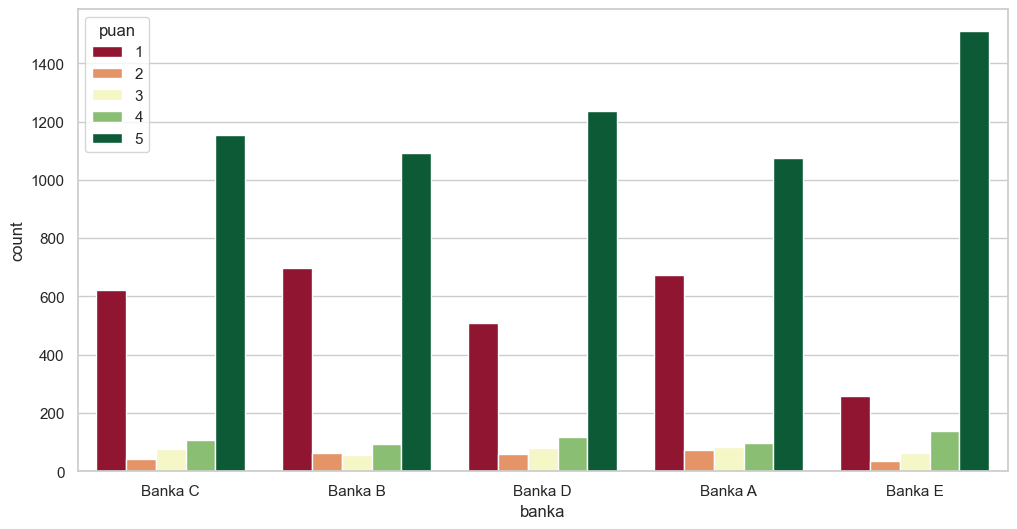

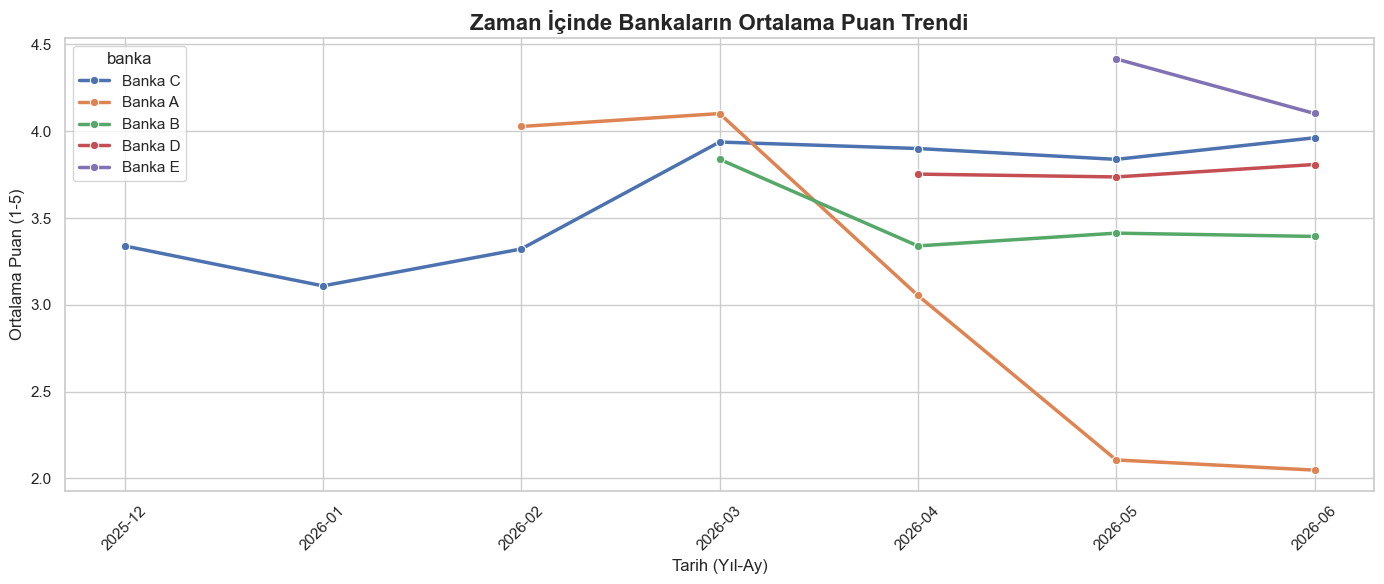

In [12]:
# KEŞİFSEL VERİ ANALİZİ (EDA)
#1. BANKA BAZINDA PUAN DAĞILIMI
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="banka", hue="puan", palette="RdYlGn")

# 2. ZAMAN SERİSİ ANALİZİ
df["tarih"]=pd.to_datetime(df["tarih"])
df["yil_ay"] = df["tarih"].dt.strftime('%Y-%m')
son_tarih = df["tarih"].max()
df_grafik = df[df["tarih"] >= son_tarih - pd.DateOffset(months=6)]
aylik_trend = df_grafik.groupby(["yil_ay","banka"])["puan"].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=aylik_trend, x="yil_ay", y="puan", hue="banka", marker="o", linewidth=2.5)

plt.title("Zaman İçinde Bankaların Ortalama Puan Trendi", fontsize=16, fontweight='bold')
plt.xlabel("Tarih (Yıl-Ay)", fontsize=12)
plt.ylabel("Ortalama Puan (1-5)", fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


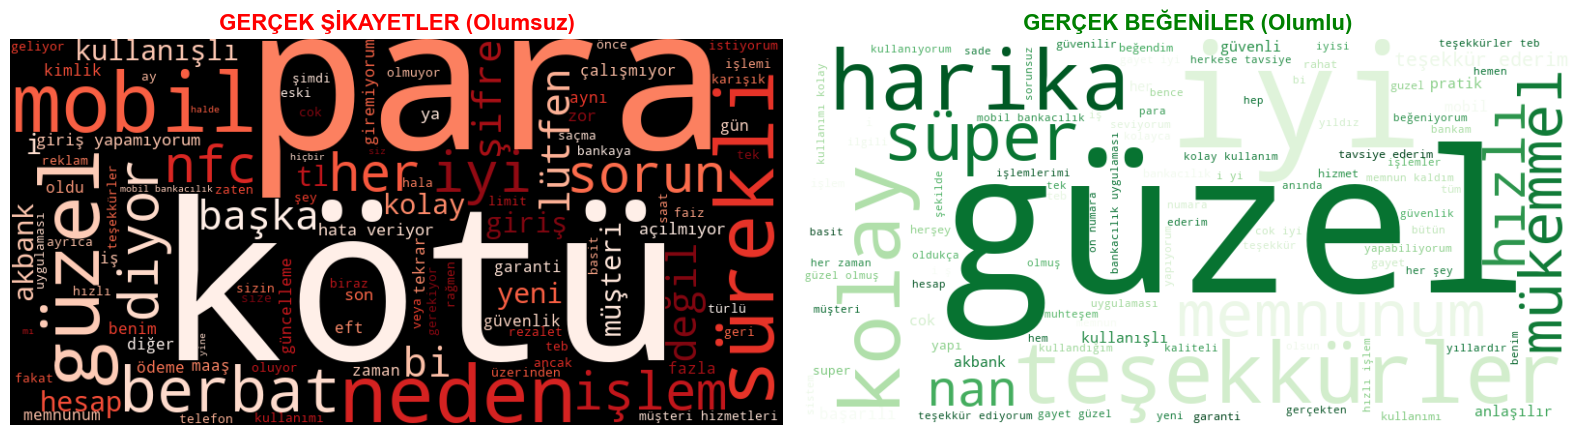

In [13]:
yasakli_kelimeler = {
    "bir", "ve", "ama", "için", "da", "de", "ile", "çok", "bu", "var", 
    "yok", "kadar", "gibi", "ben", "en", "daha", "ne", "diye", "mi", "mu",
    "olarak", "olan", "ki", "şu", "o", "böyle", "hiç", "sadece", "artık",
    "sonra", "nasıl", "bile", "kendi", "beni", "bana", "onu", "bunu",
    "uygulama", "uygulamayı", "uygulamaya", "banka", "bankası", "kredi", "kart", "kartı"
}

# 2. METİNLERİ HAZIRLAMA
olumsuz_metin = " ".join(df[df["duygu_etiketi"] == "Olumsuz"]["yorum_keyword"].astype(str))
olumlu_metin = " ".join(df[df["duygu_etiketi"] == "Olumlu"]["yorum_keyword"].astype(str))

# 3. KELİME BULUTLARINI ÇİZDİRME
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# BERTurk'ün "Olumsuz" Dedikleri 
wc_olumsuz = WordCloud(
    width=800, height=400, 
    background_color="black", 
    colormap="Reds", 
    max_words=100,
    stopwords=yasakli_kelimeler
).generate(olumsuz_metin)

axes[0].imshow(wc_olumsuz, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("GERÇEK ŞİKAYETLER (Olumsuz)", fontsize=16, color="red", fontweight='bold')

# BERTurk'ün Olumlu Dedikleri (Yeşil)
wc_olumlu = WordCloud(
    width=800, height=400, 
    background_color="white", 
    colormap="Greens", 
    max_words=100,
    stopwords=yasakli_kelimeler 
).generate(olumlu_metin)

axes[1].imshow(wc_olumlu, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("GERÇEK BEĞENİLER (Olumlu)", fontsize=16, color="green", fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\casper\AppData\Local\Temp\ipykernel_8016\2241014423.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tfidf_df, x="TF-IDF Skoru", y="Sikayet", ax=axes[i], palette="Reds_r")
C:\Users\casper\AppData\Local\Temp\ipykernel_8016\2241014423.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tfidf_df, x="TF-IDF Skoru", y="Sikayet", ax=axes[i], palette="Reds_r")
C:\Users\casper\AppData\Local\Temp\ipykernel_8016\2241014423.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tfidf_df, x="TF-IDF Skoru", y="Sikayet", ax=axes

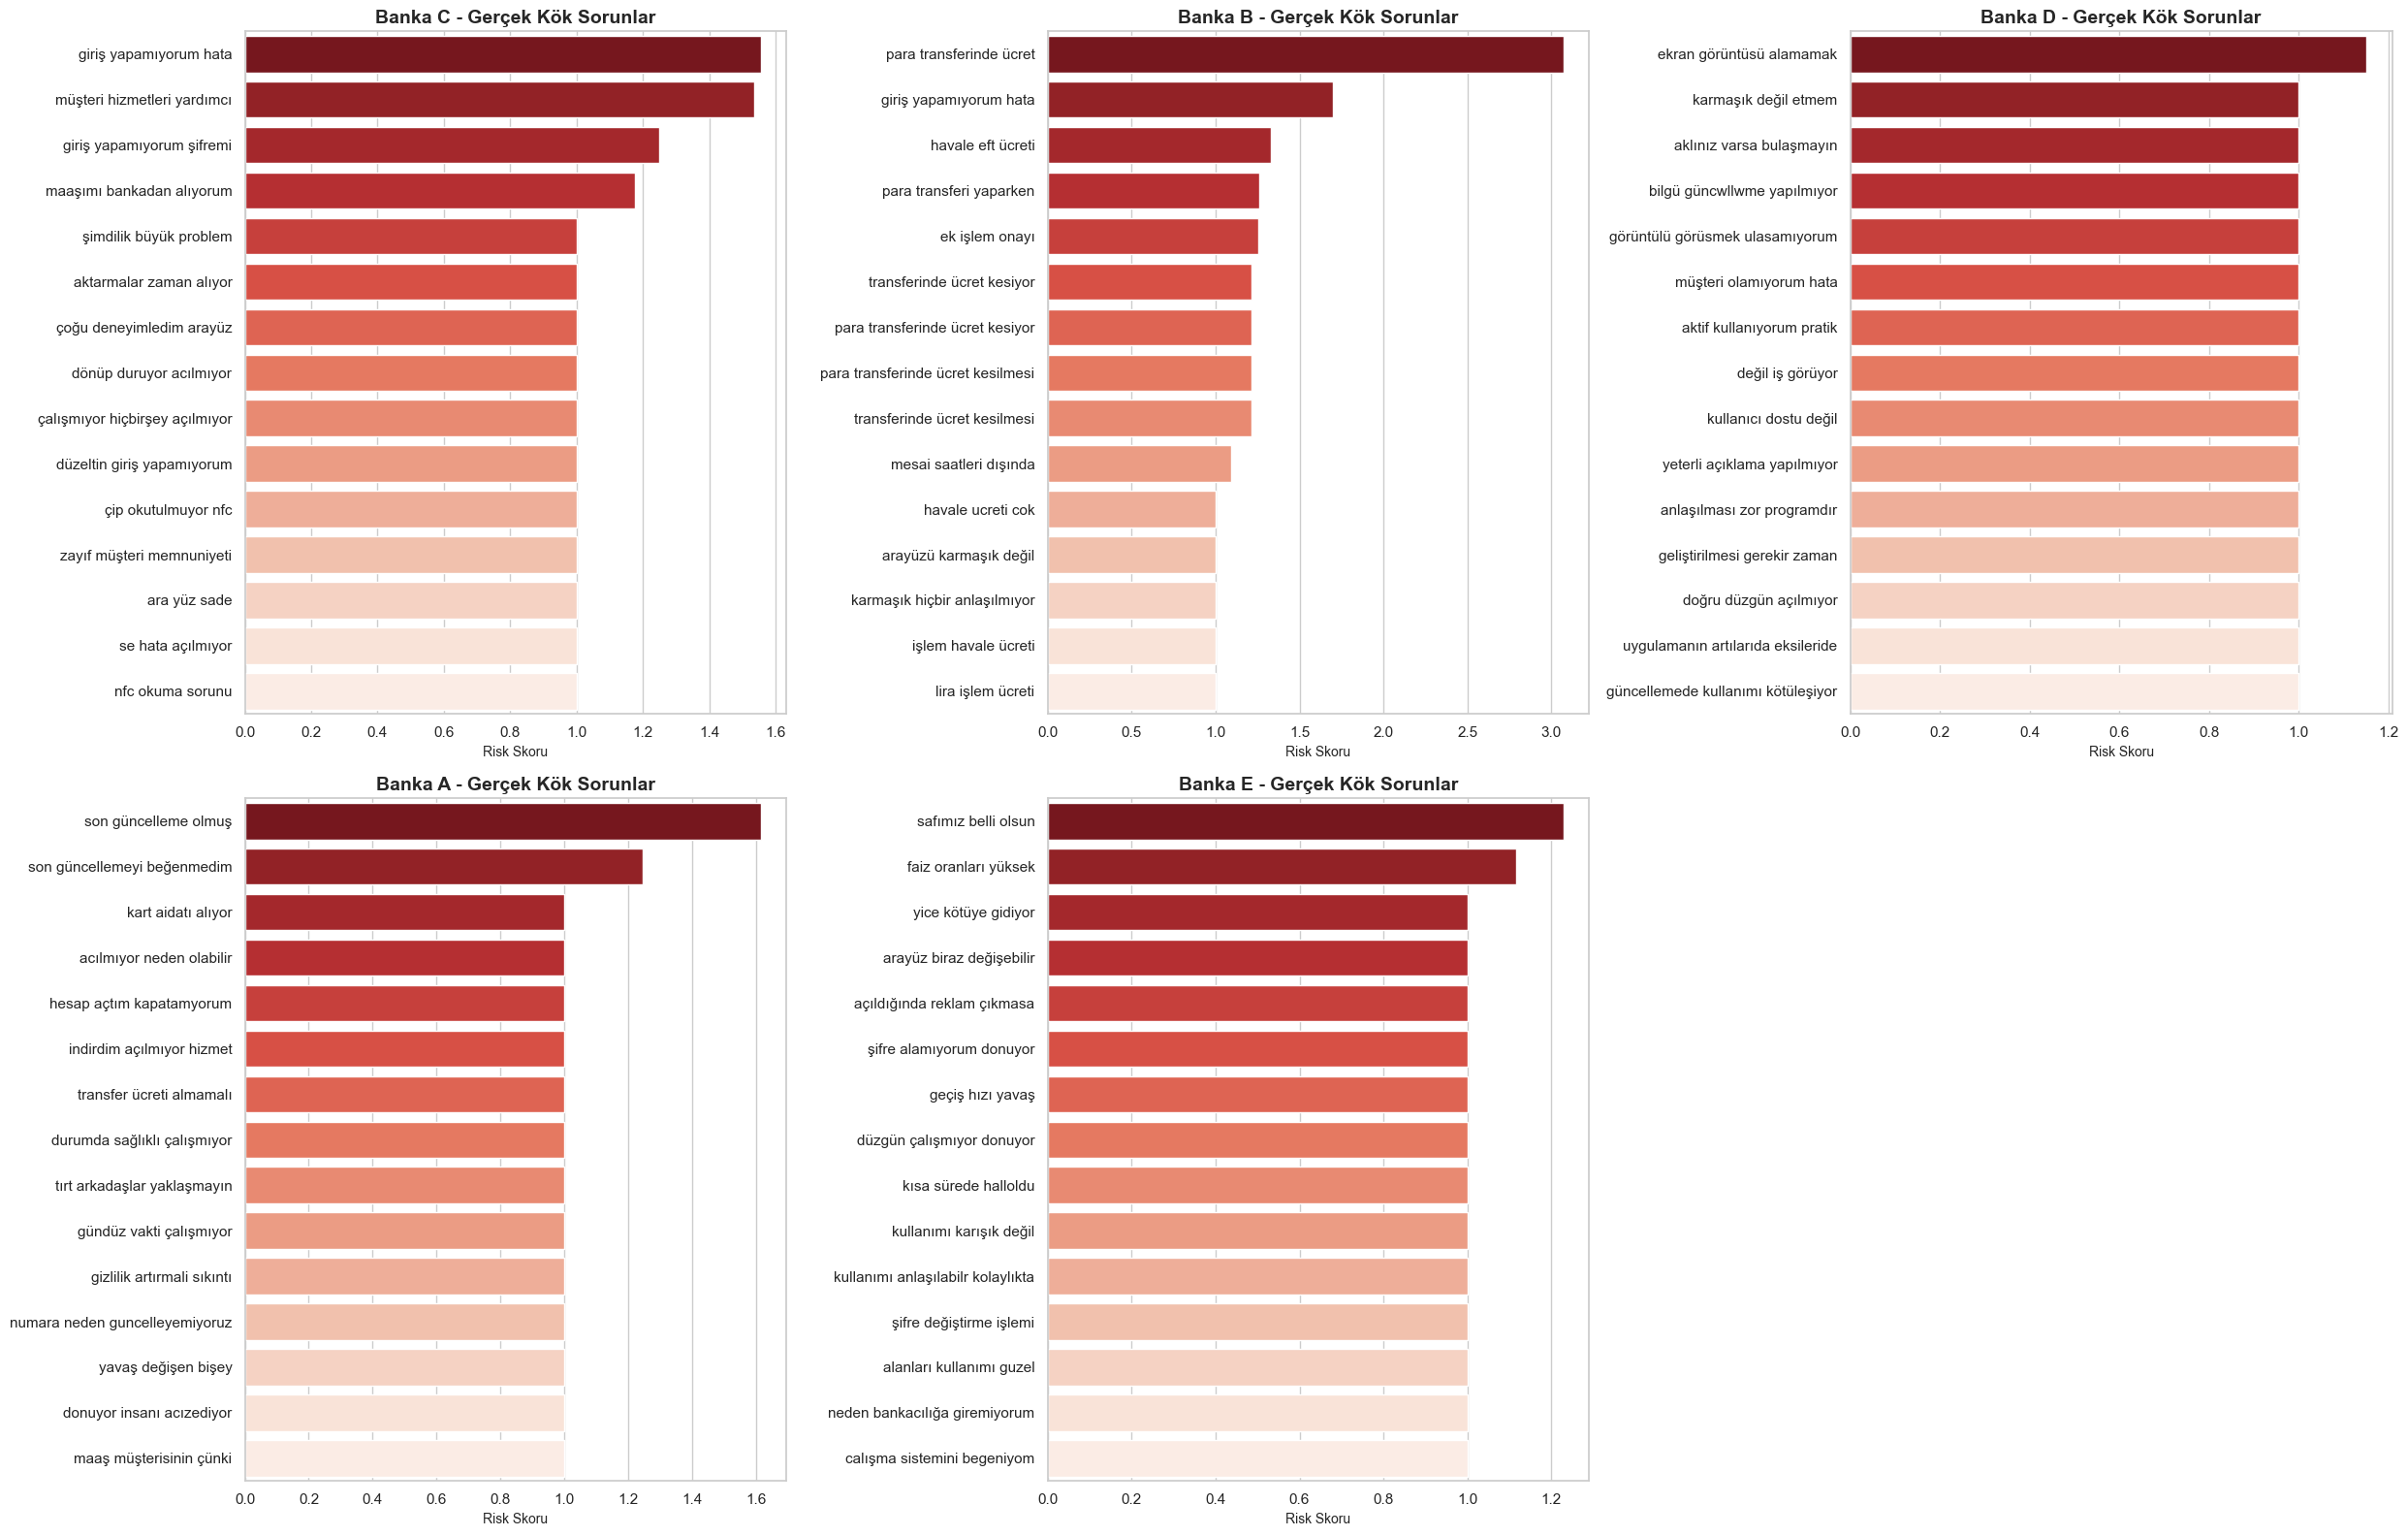

In [14]:
yasakli_kelimeler = [
    "bir", "ve", "ama", "için", "da", "de", "ile", "çok", "bu", "var", "yok",
    "kadar", "gibi", "ben", "en", "daha", "ne", "diye", "mi", "mu", "mı", "mü",
    "olarak", "olan", "ki", "şu", "o", "böyle", "hiç", "sadece", "artık", "artik",
    "sonra", "nasıl", "bile", "kendi", "beni", "bana", "onu", "bunu", "biz",
    "bizi", "bize", "siz", "size", "sizi", "her", "şey", "şeyi", "bütün", "tüm","beş",
    "bi", "falan", "filan","tavsiye",

    "uygulama", "uygulamayı", "uygulamaya", "uygulaması", "banka", "bankası",
    "bankayı", "bankanız", "mobil", "internet", 
    "teb", "cepteteb", "akbank", "garanti", "iscep", "işcep", "yapikredi", "yapı",

    "olur", "oldu", "olmuyor", "olduğu", "ediyorum", "ediyor", "yapıyor",
    "yapmıyor", "yaptım", "verdim", "aldım", "istiyorum", "istemiyorum",
    "gerekiyor", "geldi", "gitti", "çıktı", "veriyor",

    "gün", "gündür", "ay", "aydır", "yıl", "saat", "saattir", "dakika",
    "bugün", "yarın", "şimdi", "önce", "sürekli", "hep", "asla",
    "kere", "defa", "kez", "fazla", "eksik", "yine", "hala",

    "kötü", "berbat", "iyi", "memnunum", "rezalet", "gayet", "yeni",
    "saçma", "sapan", "güzel", "kolay", "basit", "rahat", "fena",
    "memnun", "değilim", "kullanışlı", "harika", "mükemmel", "iğrenç",

    "teşekkür", "ederim", "teşekkürler", "lütfen", "tavsiye", "etmiyorum",
    "olmasına", "rağmen", "başka", "diğer", "bankalarda", "bankaya", "yıldız",
    "rica", "merhaba", "selam", "sayın"
]
olumsuz_df = df[df["duygu_etiketi"]=="Olumsuz"].dropna(subset="yorum_keyword")
bankalar = olumsuz_df["banka"].unique()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25,16))
axes = axes.flatten()
sns.set_theme(style="whitegrid")
for i, banka in enumerate(bankalar):
    metinler = olumsuz_df[olumsuz_df["banka"]==banka]["yorum_keyword"]
    if len (metinler)<5:
        continue
    vectorizer = TfidfVectorizer(ngram_range=(3,4),stop_words=yasakli_kelimeler)
    X = vectorizer.fit_transform(metinler)
    skorlar = zip(vectorizer.get_feature_names_out(),X.sum(axis=0).tolist()[0])
    tfidf_df = pd.DataFrame(skorlar,columns=["Sikayet","TF-IDF Skoru"]).sort_values(by="TF-IDF Skoru",ascending=False).head(15)
    sns.barplot(data=tfidf_df, x="TF-IDF Skoru", y="Sikayet", ax=axes[i], palette="Reds_r")
    axes[i].set_title(f"{banka} - Gerçek Kök Sorunlar", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Risk Skoru", fontsize=10)
    axes[i].set_ylabel("")

if len(bankalar) < 6:
    for j in range(len(bankalar), 6):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
df["skor_0_1"] = (df["puan"] - 1) / 4
df["nlp_gercek_skor"] = np.where(df["duygu_etiketi"] == "Olumlu", df["duygu_skoru"], 1 - df["duygu_skoru"])

df["delta_skor"] = df["skor_0_1"] - df["nlp_gercek_skor"]

olumlu_isaretler = ["iyi", "güz", "guz", "memn", "kull", "harik", "kolay", "hizl", "hızl", "sag", "sağ", "teşekkür", "tesekkur"]

yeni_sinyaller = []

for d, n, puan, metin in zip(df["delta_skor"], df["nlp_gercek_skor"], df["puan"], df["yorum"]):
    metin_str = str(metin).lower().strip()
    if (puan >= 4) and any(kok in metin_str for kok in olumlu_isaretler):
        yeni_sinyaller.append("Sadık")
    elif d > 0.4:
        yeni_sinyaller.append("Sessiz Kayıp")
    elif d < -0.4:
        yeni_sinyaller.append("Hatalı Puan")
    elif n > 0.6:
        yeni_sinyaller.append("Sadık")
    else:
        yeni_sinyaller.append("Şikayetçi")

df["delta_sinyali"] = yeni_sinyaller

df.to_csv("outputs/temiz_veri_v4_delta_sinyalli.csv", index=False, encoding="utf-8-sig")

print("Dağılım:")
print(df["delta_sinyali"].value_counts())


Dağılım:
delta_sinyali
Sadık           6057
Şikayetçi       2921
Sessiz Kayıp     847
Hatalı Puan      175
Name: count, dtype: int64


In [16]:
df[df["delta_sinyali"]=="Sessiz Kayıp"]

,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,celiskili_olumlu,duygu_etiketi,duygu_skoru,yil_ay,skor_0_1,nlp_gercek_skor,delta_skor,delta_sinyali
47,Banka C,3,berbat biuygulama,2026-06-08 19:05:22,8.19.0,0,17,berbat biuygulama,berbat biuygulama,False,False,Olumsuz,0.999568,2026-06,0.50,0.000432,0.499568,Sessiz Kayıp
56,Banka C,4,şube yada internetdeki tüm işlemler maalesef yok,2026-06-08 09:32:04,8.18.0,0,48,şube yada internetdeki tüm işlemler maalesef yok,şube yada internetdeki tüm işlemler maalesef yok,False,False,Olumsuz,0.985057,2026-06,0.75,0.014943,0.735057,Sessiz Kayıp
63,Banka C,3,Kartlar bölümü çok değişmiş. Alışmak uzun zama...,2026-06-06 11:51:31,8.19.0,3,62,Kartlar bölümü çok değişmiş. Alışmak uzun zama...,kartlar bölümü çok değişmiş alışmak uzun zaman...,False,False,Olumsuz,0.999678,2026-06,0.50,0.000322,0.499678,Sessiz Kayıp
79,Banka C,5,gece 12 den sonra para transferinde neden NFC ...,2026-06-04 00:46:56,8.18.0,0,129,gece 12 den sonra para transferinde neden NFC ...,gece den sonra para transferinde neden nfc vey...,False,False,Olumsuz,0.986649,2026-06,1.00,0.013351,0.986649,Sessiz Kayıp
80,Banka C,5,helal,2026-06-03 22:11:15,8.19.0,0,5,helal,helal,False,False,Olumsuz,0.535641,2026-06,1.00,0.464359,0.535641,Sessiz Kayıp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9949,Banka E,4,eskiden ekran görüntüsü alabiliyordum artık al...,2026-05-07 22:41:59,4.0.62,0,70,eskiden ekran görüntüsü alabiliyordum artık al...,eskiden ekran görüntüsü alabiliyordum artık al...,False,False,Olumsuz,0.999182,2026-05,0.75,0.000818,0.749182,Sessiz Kayıp
9965,Banka E,5,bankanıza çalıştığım halde kıredi notum 1200 d...,2026-05-07 21:07:57,4.0.62,0,93,bankanıza çalıştığım halde kıredi notum 1200 d...,bankanıza çalıştığım halde kıredi notum diye k...,False,False,Olumsuz,0.988335,2026-05,1.00,0.011665,0.988335,Sessiz Kayıp
9976,Banka E,5,TAM BİR REZALET UYGULAMA. HERYERİ REKLAM. HER ...,2026-05-07 19:58:52,4.0.62,0,397,TAM BİR REZALET UYGULAMA. HERYERİ REKLAM. HER ...,tam bi̇r rezalet uygulama heryeri̇ reklam her ...,True,False,Olumsuz,0.999469,2026-05,1.00,0.000531,0.999469,Sessiz Kayıp
9983,Banka E,3,Para gönderme işlemler karışık biraz daha sade...,2026-05-07 19:11:23,4.0.62,0,94,Para gönderme işlemler karışık biraz daha sade...,para gönderme işlemler karışık biraz daha sade...,False,False,Olumsuz,0.998958,2026-05,0.50,0.001042,0.498958,Sessiz Kayıp


In [17]:
df["delta_sinyali"].value_counts()

delta_sinyali
Sadık           6057
Şikayetçi       2921
Sessiz Kayıp     847
Hatalı Puan      175
Name: count, dtype: int64

In [18]:
#Kanal Sürtünmesi (Friction Score)
df = pd.read_csv("outputs/temiz_veri_v4_delta_sinyalli.csv")
surtunme_kelimeleri = [
    "şifre", "nfc", "güncelleme", "ücret", "kesinti", "hata",
    "bağlanmıyor", "donuyor", "çöküyor", "açılmıyor", "giremiyorum",
    "ekran görüntüsü", "onay", "kapanıyor", "bloke", "havale", "eft",
    "işlem", "transfer", "kimlik", "müşteri hizmetleri", "temsilci"
]
def surtunme_say(metin): 
    if not isinstance(metin,str) or len(metin.strip())==0:
        return 0 
    metin_kucuk = metin.lower()
    return sum([1 for k in surtunme_kelimeleri if k in metin_kucuk])
df["surtunme_skor"]=df["yorum"].apply(surtunme_say)
yeni_dosya = "outputs/temiz_veri_v5_surtunme_skorlu.csv"
df.to_csv(yeni_dosya, index=False, encoding="utf-8-sig")
print(f" V5 Dosyası Başarıyla Kaydedildi: {yeni_dosya}")

print("\n Segmentlere Göre Ortalama Sürtünme Skorları:")
print(df.groupby("delta_sinyali")["surtunme_skor"].mean().round(2))



 V5 Dosyası Başarıyla Kaydedildi: outputs/temiz_veri_v5_surtunme_skorlu.csv

 Segmentlere Göre Ortalama Sürtünme Skorları:
delta_sinyali
Hatalı Puan     0.29
Sadık           0.11
Sessiz Kayıp    0.53
Şikayetçi       0.77
Name: surtunme_skor, dtype: float64


In [19]:
df= pd.read_csv("outputs/temiz_veri_v5_surtunme_skorlu.csv")
churn_kelimeleri = [
    "kapat", "sil", "iptal", "terk", "bırak", "birak", "geçeceğim", "gececegim",
    "başka banka", "baska banka", "kullanmayac", "kullanmıy", "vazgeç", "vazgec",
    "yeter artık", "yeter artik", "son bul", "alternatif", "bıktım", "biktim",
    "gına geldi", "gina geldi", "elveda", "nefret", "rezalet", "berbat"
]
def churn_niy_say(metin): 
    if not isinstance(metin,str) or len(metin.strip())==0:
        return 0 
    metin_kucuk = metin.lower()
    return sum([1 for k in churn_kelimeleri if k in metin_kucuk])
df["churn_niyet_skor"]=df["yorum"].apply(churn_niy_say)
yeni_dosya = "outputs/temiz_veri_v6_churn_skorlu.csv"
df.to_csv(yeni_dosya, index=False, encoding="utf-8-sig")
print(f" V6 Dosyası Başarıyla Kaydedildi: {yeni_dosya}")

print("\n Segmentlere Göre Ortalama Churn Skorları:")
print(df.groupby("delta_sinyali")["churn_niyet_skor"].mean().round(3))



 V6 Dosyası Başarıyla Kaydedildi: outputs/temiz_veri_v6_churn_skorlu.csv

 Segmentlere Göre Ortalama Churn Skorları:
delta_sinyali
Hatalı Puan     0.034
Sadık           0.020
Sessiz Kayıp    0.111
Şikayetçi       0.291
Name: churn_niyet_skor, dtype: float64


In [3]:
df= pd.read_csv("outputs/temiz_veri_v6_churn_skorlu.csv")
df=df[~(df["delta_sinyali"] == "Hatalı Puan")]
df["delta_sinyali"].value_counts()



delta_sinyali
Sadık           6057
Şikayetçi       2921
Sessiz Kayıp     847
Name: count, dtype: int64

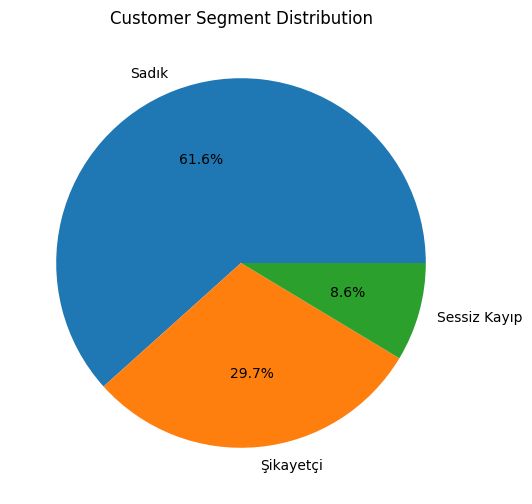

In [4]:
plt.figure(figsize=(6,6))

df["delta_sinyali"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Segment Distribution")

plt.show()

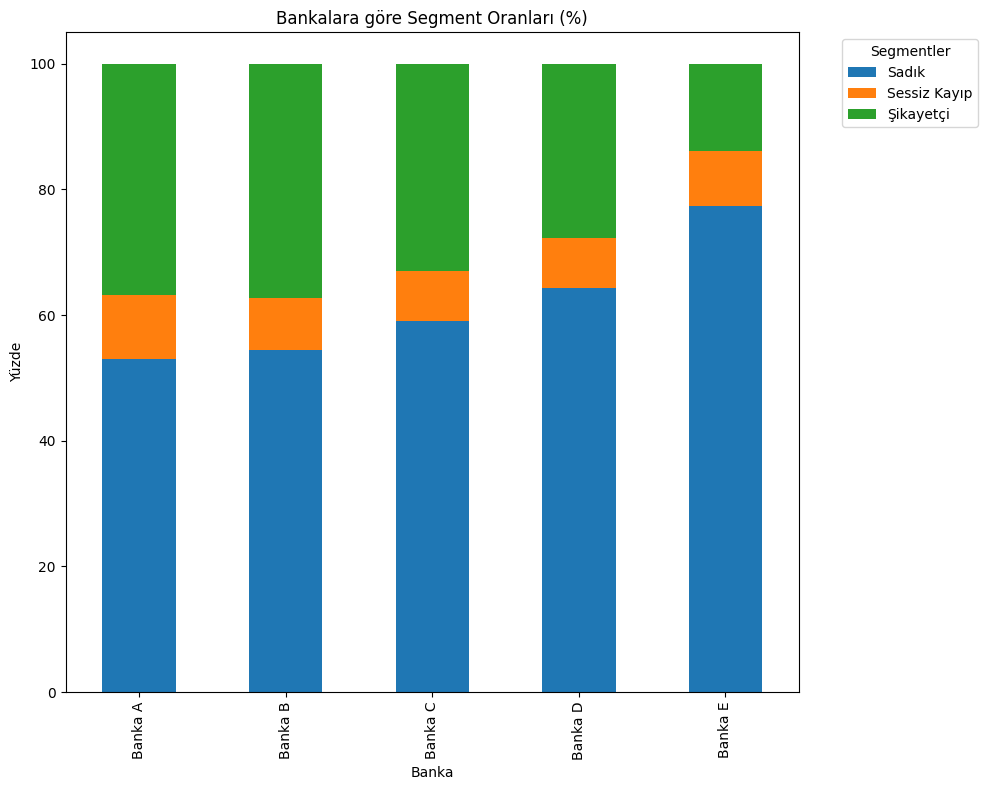

In [10]:
segment_banka = pd.crosstab(
    df["banka"],
    df["delta_sinyali"],
    normalize="index"
) * 100

segment_banka.plot(
    kind="bar",
    stacked=True,
    figsize=(10,8)
)

plt.title("Bankalara göre Segment Oranları (%)")
plt.xlabel("Banka")
plt.ylabel("Yüzde")
plt.legend(title="Segment")
plt.legend(title='Segmentler', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Kriz döneminde Banka A olumsuz yorum sayısı: 815
Ortalama puan: 2.16

 Banka A  Kriz Dönemi — En Kritik Şikayet Öbekleri:
                                 Sikayet     Skor
                eski haline geri getirin 3.000000
          geçici süre hizmet veremiyoruz 2.000000
               üyelik ücreti adı altında 2.000000
         sabahtan beri giriş yapamıyorum 2.000000
          otomatik fatura ödeme talimatı 1.707107
               chip para gelmedi müşteri 1.707107
               artı para kullanım ücreti 1.000000
       şubeye gittiğimde limit yükseltme 1.000000
şubeye yönlendiriyor şubede yükseltmiyor 1.000000
   şubeye yönlendiriyor şubeye gidiyorum 1.000000
      şunu hiçbirşey yapamıyorsanız eski 1.000000
               şuursuz bankadir ya giriş 1.000000
            şöyle derler reklam yaparlar 1.000000
            şöyle genel işlemler sayfası 1.000000
          şüphe etsem kimselere ulaşamam 1.000000
         şüpheli işlem bildirimi müşteri 1.000000
         şüpheli işlem bildi

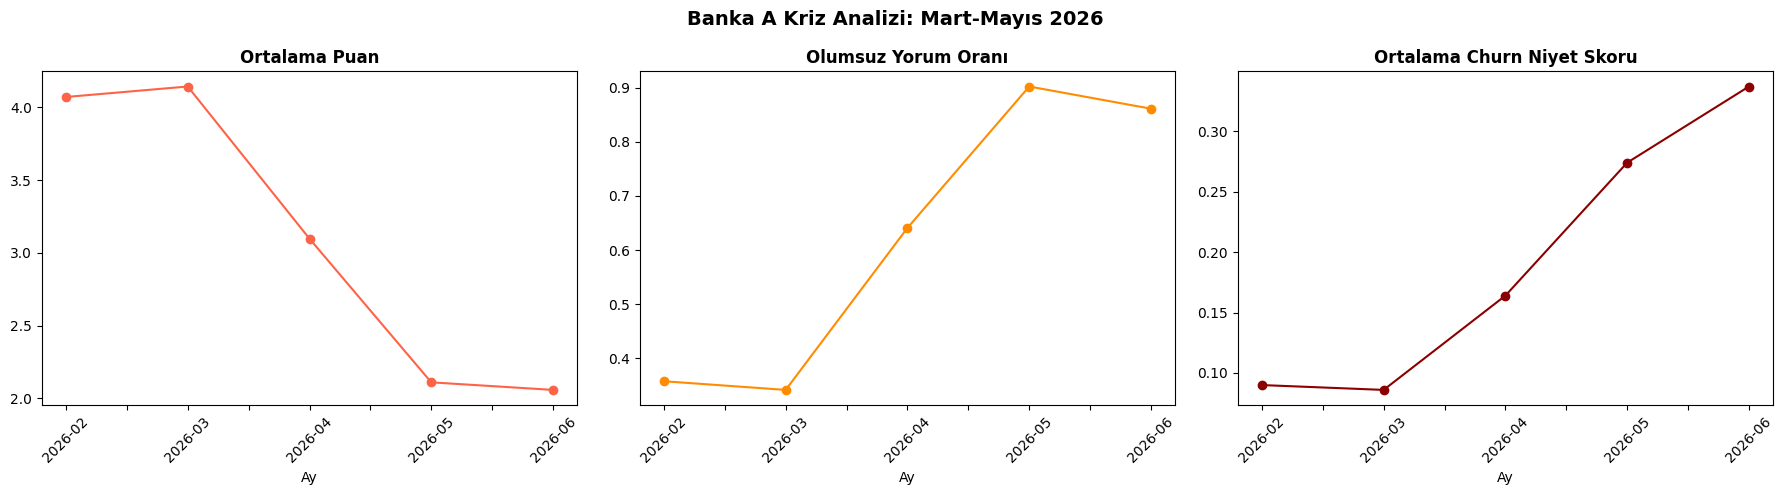

In [31]:
#BANKA A KRIZ DONEMİ
yasakli_kelimeler = [
    "bir", "ve", "ama", "için", "da", "de", "ile", "çok", "bu", "var", "yok",
    "kadar", "gibi", "ben", "en", "daha", "ne", "diye", "mi", "mu", "mı", "mü",
    "olarak", "olan", "ki", "şu", "o", "böyle", "hiç", "sadece", "artık", "artik",
    "sonra", "nasıl", "bile", "kendi", "beni", "bana", "onu", "bunu", "biz",
    "bizi", "bize", "siz", "size", "sizi", "her", "şey", "şeyi", "bütün", "tüm", "beş",
    "bi", "falan", "filan", "tavsiye",

    "uygulama", "uygulamayı", "uygulamaya", "uygulaması", "banka", "bankası",
    "bankayı", "bankanız", "mobil", "internet",
    "teb", "cepteteb", "akbank", "garanti", "iscep", "işcep", "yapikredi", "yapı",

    "olur", "oldu", "olmuyor", "olduğu", "ediyorum", "ediyor", "yapıyor",
    "yapmıyor", "yaptım", "verdim", "aldım", "istiyorum", "istemiyorum",
    "gerekiyor", "geldi", "gitti", "çıktı", "veriyor","güvenlik","görevli",

    "gün", "gündür", "ay", "aydır", "yıl", "saat", "saattir", "dakika",
    "bugün", "yarın", "şimdi", "önce", "sürekli", "hep", "asla",
    "kere", "defa", "kez", "fazla", "eksik", "yine", "hala",

    "kötü", "berbat", "iyi", "memnunum", "rezalet", "gayet", "yeni",
    "saçma", "sapan", "güzel", "kolay", "basit", "rahat", "fena",
    "memnun", "değilim", "kullanışlı", "harika", "mükemmel", "iğrenç",

    "teşekkür", "ederim", "teşekkürler", "lütfen", "tavsiye", "etmiyorum",
    "olmasına", "rağmen", "başka", "diğer", "bankalarda", "bankaya", "yıldız",
    "rica", "merhaba", "selam", "sayın"
]

df["tarih"] = pd.to_datetime(df["tarih"], errors="coerce")  
banka_a_kriz = df[
    (df["banka"] == "Banka A") &
    (df["tarih"] >= "2026-03-01") &
    (df["tarih"] <= "2026-05-31") &
    (df["duygu_etiketi"] == "Olumsuz")
].copy()

print(f"Kriz döneminde Banka A olumsuz yorum sayısı: {len(banka_a_kriz)}")
print(f"Ortalama puan: {banka_a_kriz['puan'].mean():.2f}")
#EN ÇOK GEÇEN ŞİKAYET KELİMELERİ (TF-IDF ile)
metinler = banka_a_kriz["yorum_keyword"].dropna()
vectorizer = TfidfVectorizer(
    ngram_range=(4, 4),       
    stop_words=yasakli_kelimeler,
    max_features=20
)

X = vectorizer.fit_transform(metinler)
skorlar = zip(
    vectorizer.get_feature_names_out(),
    X.sum(axis=0).tolist()[0]
)

tfidf_df = pd.DataFrame(skorlar, columns=["Sikayet", "Skor"]) \
             .sort_values("Skor", ascending=False)

print("\n Banka A  Kriz Dönemi — En Kritik Şikayet Öbekleri:")
print(tfidf_df.to_string(index=False))
# AYLIK KARŞILAŞTIRMA — krizden önce vs sonra
banka_a_tum = df[df["banka"] == "Banka A"].copy()
banka_a_tum["yil_ay"] = banka_a_tum["tarih"].dt.to_period("M").astype(str)

aylik_ozet = banka_a_tum.groupby("yil_ay").agg(
    yorum_sayisi   = ("yorum", "count"),
    ort_puan       = ("puan", "mean"),
    olumsuz_oran   = ("duygu_etiketi", lambda x: (x == "Olumsuz").mean()),
    ort_surtunme   = ("surtunme_skor", "mean"),
    ort_churn      = ("churn_niyet_skor", "mean")
).round(3)

print("\n Banka A Aylık Tablo:")
print(aylik_ozet.to_string())
# GÖRSELLEŞTİRME
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

aylik_ozet["ort_puan"].plot(ax=axes[0], marker="o", color="tomato")
axes[0].set_title("Ortalama Puan", fontweight="bold")
axes[0].set_xlabel("Ay")
axes[0].tick_params(axis="x", rotation=45)

aylik_ozet["olumsuz_oran"].plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Olumsuz Yorum Oranı", fontweight="bold")
axes[1].set_xlabel("Ay")
axes[1].tick_params(axis="x", rotation=45)

aylik_ozet["ort_churn"].plot(ax=axes[2], marker="o", color="darkred")
axes[2].set_title("Ortalama Churn Niyet Skoru", fontweight="bold")
axes[2].set_xlabel("Ay")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Banka A Kriz Analizi: Mart-Mayıs 2026", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [32]:
df.head()

,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,celiskili_olumlu,duygu_etiketi,duygu_skoru,yil_ay,skor_0_1,nlp_gercek_skor,delta_skor,delta_sinyali,surtunme_skor,churn_niyet_skor
0,Banka C,5,🤩🤩🤩,2026-06-15 15:56:58,8.19.1,0,3,🤩🤩🤩,NaN,False,False,Olumlu,0.992207,2026-06,1.0,0.992207,0.007793,Sadık,0,0
1,Banka C,5,Teşekkürler,2026-06-15 13:48:58,8.19.1,0,11,Teşekkürler,teşekkürler,False,False,Olumlu,0.972303,2026-06,1.0,0.972303,0.027697,Sadık,0,0
2,Banka C,1,müşteri ol kısmı çalışmıyor,2026-06-15 12:47:46,8.19.1,0,27,müşteri ol kısmı çalışmıyor,müşteri ol kısmı çalışmıyor,False,False,Olumsuz,0.998315,2026-06,0.0,0.001685,-0.001685,Şikayetçi,0,0
3,Banka C,5,çok iyi,2026-06-15 10:33:16,8.18.0,0,7,çok iyi,çok iyi,False,False,Olumlu,0.991206,2026-06,1.0,0.991206,0.008794,Sadık,0,0
4,Banka C,5,Çok kullanışlı memnunum her işimi kolaylıkla h...,2026-06-15 10:04:48,8.19.0,14,70,Çok kullanışlı memnunum her işimi kolaylıkla h...,çok kullanışlı memnunum her işimi kolaylıkla h...,False,False,Olumlu,0.672161,2026-06,1.0,0.672161,0.327839,Sadık,0,0


In [33]:
# BANKA BAZINDA CHURN RİSKİ
df.groupby("banka")[["surtunme_skor", "churn_niyet_skor"]].mean()

,surtunme_skor,churn_niyet_skor
banka,,
Banka A,0.338603,0.147884
Banka B,0.439796,0.116837
Banka C,0.421772,0.121013
Banka D,0.280773,0.081892
Banka E,0.218543,0.073357


In [34]:
df[["surtunme_skor", "churn_niyet_skor"]].describe()

,surtunme_skor,churn_niyet_skor
count,9825.000000,9825.000000
mean,0.339949,0.108193
std,0.737999,0.358981
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,6.000000,3.000000


In [35]:
#FEATURE ENGINEERING
df["emoji_sayisi"] = df["yorum"].apply(
    lambda x: emoji.emoji_count(str(x))
)
df["major_version"] = (
    df["uygulama_versiyonu"]
    .str.extract(r"^(\d+)")
)
df["major_version"] = df["major_version"].fillna("Bilinmiyor")

le = LabelEncoder()
df["major_version_encoded"] = le.fit_transform(df["major_version"])

df["unlem_sayisi"] = df["yorum"].str.count("!")
df["soru_isareti_sayisi"] = df["yorum"].str.count(r"\?")
df["buyuk_harf_sayisi"] = df["yorum"].str.count(r"[A-ZÇĞİÖŞÜ]")
df.head()


,banka,puan,yorum,tarih,uygulama_versiyonu,begeni_sayisi,yorum_uzunluk,yorum_bert,yorum_keyword,celiskili_kizgin,...,delta_skor,delta_sinyali,surtunme_skor,churn_niyet_skor,emoji_sayisi,major_version,major_version_encoded,unlem_sayisi,soru_isareti_sayisi,buyuk_harf_sayisi
0,Banka C,5,🤩🤩🤩,2026-06-15 15:56:58,8.19.1,0,3,🤩🤩🤩,NaN,False,...,0.007793,Sadık,0,0,3,8,15,0,0,0
1,Banka C,5,Teşekkürler,2026-06-15 13:48:58,8.19.1,0,11,Teşekkürler,teşekkürler,False,...,0.027697,Sadık,0,0,0,8,15,0,0,1
2,Banka C,1,müşteri ol kısmı çalışmıyor,2026-06-15 12:47:46,8.19.1,0,27,müşteri ol kısmı çalışmıyor,müşteri ol kısmı çalışmıyor,False,...,-0.001685,Şikayetçi,0,0,0,8,15,0,0,0
3,Banka C,5,çok iyi,2026-06-15 10:33:16,8.18.0,0,7,çok iyi,çok iyi,False,...,0.008794,Sadık,0,0,0,8,15,0,0,0
4,Banka C,5,Çok kullanışlı memnunum her işimi kolaylıkla h...,2026-06-15 10:04:48,8.19.0,14,70,Çok kullanışlı memnunum her işimi kolaylıkla h...,çok kullanışlı memnunum her işimi kolaylıkla h...,False,...,0.327839,Sadık,0,0,0,8,15,0,0,1


In [106]:
# 3 SEGMENTLİ LOJİSTİK REGRESYON
X=df[["surtunme_skor","churn_niyet_skor","yorum_uzunluk","emoji_sayisi"]]
y= df["delta_sinyali"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)
model=LogisticRegression(solver="lbfgs",max_iter=1000,random_state=42)
cv_skor= cross_val_score(model,X_train,y_train,cv=5, scoring="accuracy")
cv_skor = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print("5-Katlı Cross-Validation Sınav Sonuçları:")
for i, skor in enumerate(cv_skor, 1):
    print(f"  Sınav {i}: %{skor*100:.2f}")

cv_ortalama = cv_skor.mean()
print(f"\n GÜVENİLİR EĞİTİM BAŞARISI (CV Ortalaması): %{cv_ortalama*100:.2f}")
model.fit(X_train,y_train)
y_test_pred = model.predict(X_test)
print("3 SEGMENTLİ LOJİSTİK REGRESYON FINAL TEST BAŞARI RAPORU")
print("=========================================")
print(classification_report(y_test, y_test_pred))
print(f"Genel Doğruluk Oranı (Final Test Accuracy): %{accuracy_score(y_test, y_test_pred)*100:.2f}")


5-Katlı Cross-Validation Sınav Sonuçları:
  Sınav 1: %74.56
  Sınav 2: %74.49
  Sınav 3: %73.96
  Sınav 4: %73.82
  Sınav 5: %73.09

 GÜVENİLİR EĞİTİM BAŞARISI (CV Ortalaması): %73.99
3 SEGMENTLİ LOJİSTİK REGRESYON FINAL TEST BAŞARI RAPORU
              precision    recall  f1-score   support

       Sadık       0.76      0.92      0.83      1817
Sessiz Kayıp       0.00      0.00      0.00       254
   Şikayetçi       0.69      0.59      0.63       877

    accuracy                           0.74      2948
   macro avg       0.48      0.50      0.49      2948
weighted avg       0.67      0.74      0.70      2948

Genel Doğruluk Oranı (Final Test Accuracy): %74.32


c:\Users\casper\miniconda3\envs\PythonProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\casper\miniconda3\envs\PythonProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\casper\miniconda3\envs\PythonProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

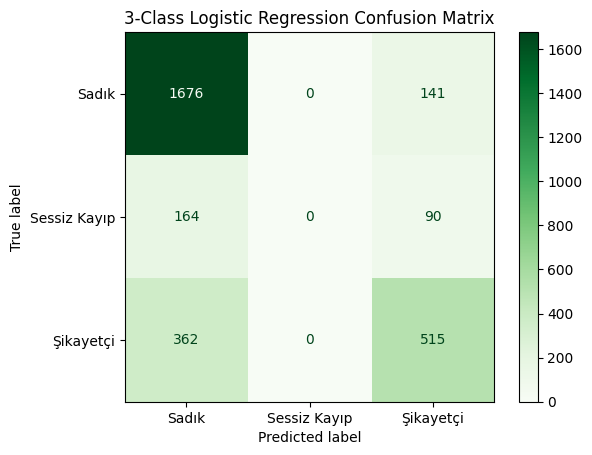

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("3-Class Logistic Regression Confusion Matrix")
plt.show()

In [108]:
# 3 SEGMENTLİ RANDOM FOREST
rf_model= RandomForestClassifier(n_estimators=100,max_depth=5,class_weight="balanced")
cv_skor_rf =cross_val_score(rf_model,X_train,y_train,cv=5,scoring="accuracy")
for i, skor in enumerate(cv_skor_rf, 1):
    print(f"  Sınav {i}: %{skor*100:.2f}")

print(f"\n GÜVENİLİR EĞİTİM BAŞARISI (RF Ortalaması): %{cv_skor_rf.mean()*100:.2f}")
rf_model.fit(X_train,y_train)
y_test_predict_rf = rf_model.predict(X_test)
print(" NİHAİ TEST (FINAL TEST) RAPORU - RANDOM FOREST")
print("=========================================")
print(classification_report(y_test, y_test_predict_rf))

  Sınav 1: %67.59
  Sınav 2: %68.24
  Sınav 3: %66.04
  Sınav 4: %66.62
  Sınav 5: %62.47

 GÜVENİLİR EĞİTİM BAŞARISI (RF Ortalaması): %66.19
 NİHAİ TEST (FINAL TEST) RAPORU - RANDOM FOREST
              precision    recall  f1-score   support

       Sadık       0.88      0.75      0.81      1817
Sessiz Kayıp       0.14      0.31      0.19       254
   Şikayetçi       0.63      0.60      0.62       877

    accuracy                           0.67      2948
   macro avg       0.55      0.55      0.54      2948
weighted avg       0.74      0.67      0.70      2948



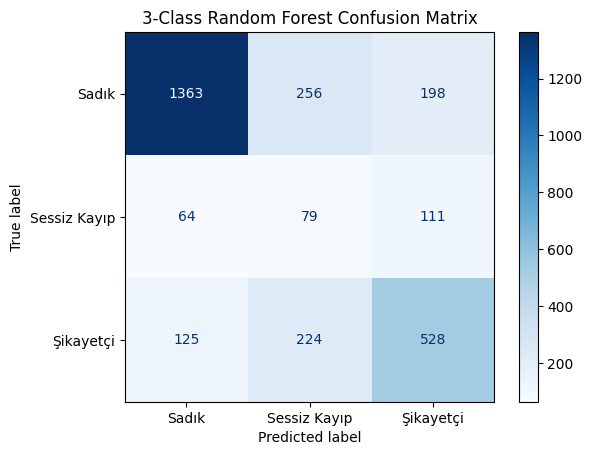

In [109]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("3-Class Random Forest Confusion Matrix")
plt.show()

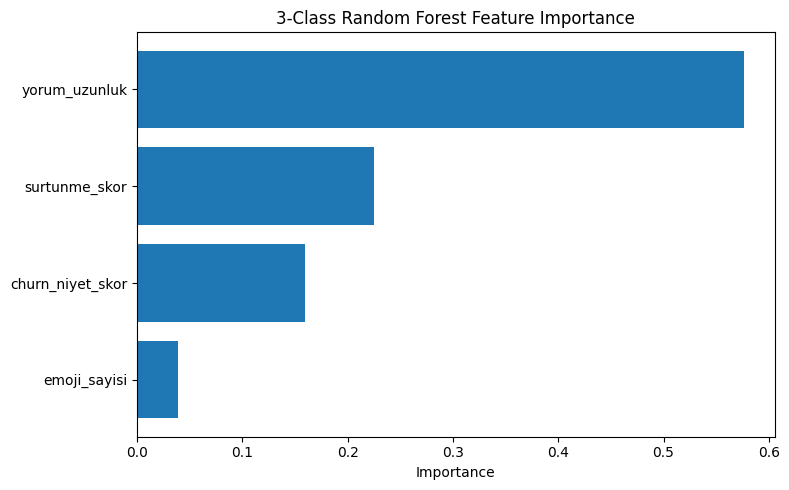

In [110]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])

plt.xlabel("Importance")
plt.title("3-Class Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [111]:
uc_sonuc = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_test_predict_rf),
        accuracy_score(y_test, y_test_pred)
    ],

    "Precision":[
        precision_score(y_test, y_test_predict_rf, average="weighted"),
        precision_score(y_test, y_test_pred, average="weighted")
    ],

    "Recall":[
        recall_score(y_test, y_test_predict_rf, average="weighted"),
        recall_score(y_test, y_test_pred, average="weighted")
    ],

    "F1 Score":[
        f1_score(y_test, y_test_predict_rf, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted")
    ]

})

display(uc_sonuc.round(3))

c:\Users\casper\miniconda3\envs\PythonProject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.668,0.741,0.668,0.699
1,Logistic Regression,0.743,0.674,0.743,0.703


In [112]:
# 2 SEGMENTLİ RANDOM FOREST
df["ikili_sinif"]=df["delta_sinyali"].replace({"Sessiz Kayıp":"Riskli","Şikayetçi":"Riskli","Sadık":"Sadık"})
X_ikili=df[["surtunme_skor","churn_niyet_skor","yorum_uzunluk","emoji_sayisi"]]
y_ikili = df["ikili_sinif"]
X_train,X_test,y_train,y_test = train_test_split(X_ikili,y_ikili,test_size=0.30,random_state=42,stratify=y_ikili)
rf_ikili_model = RandomForestClassifier(n_estimators=100,max_depth=5,class_weight="balanced",random_state=42)
cv_skor_ikili = cross_val_score(rf_ikili_model,X_train,y_train,cv=5,scoring="accuracy")
print(" İki segmentli 5-Katlı Sınav Sonuçları:")
for i, skor in enumerate(cv_skor_ikili, 1):
    print(f"  Sınav {i}: %{skor*100:.2f}")

print(f"\n GÜVENİLİR EĞİTİM BAŞARISI: %{cv_skor_ikili.mean()*100:.2f}")

rf_ikili_model.fit(X_train,y_train)
y_test_predict_rf_ikili = rf_ikili_model.predict(X_test)
print(" 2 SINIFLI RANDOM FOREST FINAL TEST RAPORU")
print("=========================================")
print(classification_report(y_test, y_test_predict_rf_ikili))

 İki segmentli 5-Katlı Sınav Sonuçları:
  Sınav 1: %78.27
  Sınav 2: %79.36
  Sınav 3: %78.55
  Sınav 4: %78.04
  Sınav 5: %79.85

 GÜVENİLİR EĞİTİM BAŞARISI: %78.81
 2 SINIFLI RANDOM FOREST FINAL TEST RAPORU
              precision    recall  f1-score   support

      Riskli       0.68      0.80      0.74      1131
       Sadık       0.86      0.77      0.81      1817

    accuracy                           0.78      2948
   macro avg       0.77      0.78      0.77      2948
weighted avg       0.79      0.78      0.78      2948



In [113]:
# 2 SEGMENTLİ LOJİSTİK REGRESYON
log_iki_model = LogisticRegression(class_weight="balanced",random_state=42)
cv_skor_log_iki = cross_val_score(log_iki_model,X_train,y_train,cv=5,scoring="accuracy")
log_iki_model.fit(X_train,y_train)
y_test_pred_log_iki = log_iki_model.predict(X_test)
print(" İKİ SEGMENTLİ LOJİSTİK REGRESYON NİHAİ TEST RAPORU")
print("=========================================")
print(classification_report(y_test, y_test_pred_log_iki))
print("Özellik Katsayıları (Coefficients):", log_iki_model.coef_)
print("Model Sabiti (Intercept):", log_iki_model.intercept_)

 İKİ SEGMENTLİ LOJİSTİK REGRESYON NİHAİ TEST RAPORU
              precision    recall  f1-score   support

      Riskli       0.75      0.68      0.72      1131
       Sadık       0.81      0.86      0.84      1817

    accuracy                           0.79      2948
   macro avg       0.78      0.77      0.78      2948
weighted avg       0.79      0.79      0.79      2948

Özellik Katsayıları (Coefficients): [[-1.0063772  -1.83104195 -0.01274974  0.71575551]]
Model Sabiti (Intercept): [1.18611151]


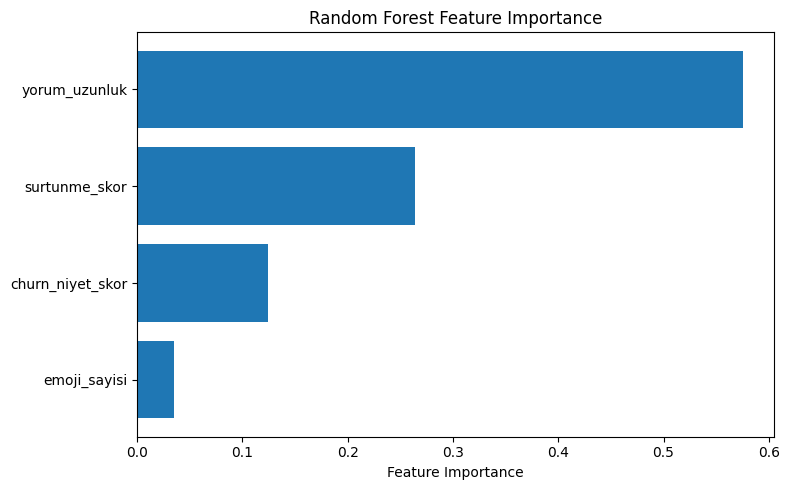

In [114]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_ikili_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [115]:
df.groupby(["banka", "ikili_sinif"])["churn_niyet_skor"].mean().unstack()
df.groupby(["banka", "ikili_sinif"])["yorum_uzunluk"].mean().unstack()

ikili_sinif,Riskli,Sadık
banka,,
Banka A,137.932609,37.587896
Banka B,105.270997,31.833177
Banka C,132.097531,43.584549
Banka D,113.153846,32.638449
Banka E,111.334086,40.984211


In [116]:
df.groupby(["banka", "ikili_sinif"])["yorum_uzunluk"].mean().unstack()

ikili_sinif,Riskli,Sadık
banka,,
Banka A,137.932609,37.587896
Banka B,105.270997,31.833177
Banka C,132.097531,43.584549
Banka D,113.153846,32.638449
Banka E,111.334086,40.984211


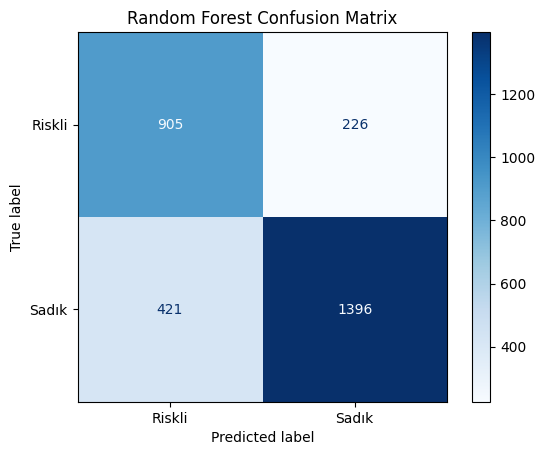

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_ikili_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

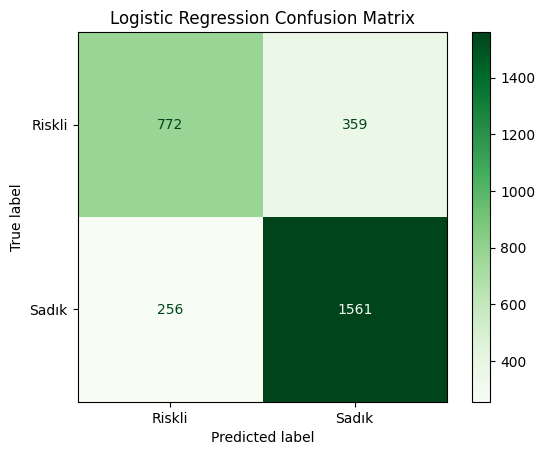

In [119]:
ConfusionMatrixDisplay.from_estimator(
    log_iki_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

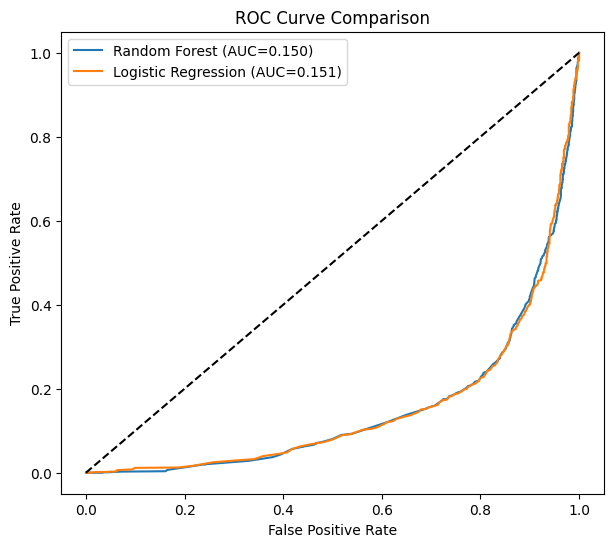

In [ ]:
y_test_binary = y_test.map({
    "Sadık": 0,
    "Riskli": 1
})
rf_probs = rf_ikili_model.predict_proba(X_test)[:, 1]
log_probs = log_iki_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, _ = roc_curve(y_test_binary, rf_probs)
log_fpr, log_tpr, _ = roc_curve(y_test_binary, log_probs)

rf_auc = auc(rf_fpr, rf_tpr)
log_auc = auc(log_fpr, log_tpr)

plt.figure(figsize=(7,6))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_auc:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" 2 Segment ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:


sonuclar = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_test_predict_rf_ikili),
        accuracy_score(y_test, y_test_pred_log_iki)
    ],
    "Precision": [
        precision_score(y_test, y_test_predict_rf_ikili, pos_label="Riskli"),
        precision_score(y_test, y_test_pred_log_iki, pos_label="Riskli")
    ],
    "Recall": [
        recall_score(y_test, y_test_predict_rf_ikili, pos_label="Riskli"),
        recall_score(y_test, y_test_pred_log_iki, pos_label="Riskli")
    ],
    "F1 Score": [
        f1_score(y_test, y_test_predict_rf_ikili, pos_label="Riskli"),
        f1_score(y_test, y_test_pred_log_iki, pos_label="Riskli")
    ]
})

sonuclar = sonuclar.round(3)
display(sonuclar)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.781,0.683,0.800,0.737
1,Logistic Regression,0.791,0.751,0.683,0.715


In [ ]:
#EN SON ÖZET TABLO
final_ozet = pd.concat(
    [
        uc_sonuc.assign(Problem="3 Segment"),
        sonuclar.assign(Problem="2 Segment")
    ],
    ignore_index=True
)

final_ozet = final_ozet[
    ["Problem","Model","Accuracy","Precision","Recall","F1 Score"]
]

display(final_ozet.round(3))

,Problem,Model,Accuracy,Precision,Recall,F1 Score
0,3 Segment,Random Forest,0.668,0.741,0.668,0.699
1,3 Segment,Logistic Regression,0.743,0.674,0.743,0.703
2,2 Segment,Random Forest,0.781,0.683,0.800,0.737
3,2 Segment,Logistic Regression,0.791,0.751,0.683,0.715
